# Problem Set 5A - Solutions

Instructor / TA copy. Run with the `data` folder in the same directory.


## Question 1. Array attributes, reshaping and views

Create the array `a = np.arange(24)`.

1. Print its `size`, `ndim`, `dtype`, `itemsize` and `nbytes`. In one sentence,
   say how `nbytes` is related to `size` and `itemsize`.
2. Reshape `a` into `b` of shape `(4, 6)` and into `c` of shape `(2, 3, 4)`.
   Print the shape of each.
3. Set `b[0, 0] = -1` and then print `a[0]`. Explain in one sentence what this
   tells you about the array returned by `reshape`.
4. Now build `d = a.reshape(4, 6).copy()`, set `d[0, 0] = 99` and print `a[0]`
   again. Explain the difference from part 3.
5. Print the shape of `a.reshape(3, -1)` and say in one sentence what `-1`
   does.

`reshape` returns a *view* whenever it can, that is, a second array object that
shares the same block of memory as the original. Writing through the view
therefore changes the original. Use `.copy()` when you want a genuinely
independent array. In `reshape`, at most one dimension may be given as `-1`,
and NumPy then works that dimension out from the total size.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

a = np.arange(24)
print("size    :", a.size)
print("ndim    :", a.ndim)
print("dtype   :", a.dtype)
print("itemsize:", a.itemsize)
print("nbytes  :", a.nbytes)
# nbytes = size * itemsize, i.e. the number of elements times the bytes each
# element occupies.

b = a.reshape(4, 6)
c = a.reshape(2, 3, 4)
print("b.shape :", b.shape)
print("c.shape :", c.shape)

b[0, 0] = -1
print("a[0] after b[0, 0] = -1 :", a[0])
# reshape returned a view: b shares memory with a, so writing to b changes a.

d = a.reshape(4, 6).copy()
d[0, 0] = 99
print("a[0] after d[0, 0] = 99 :", a[0])
# .copy() makes an independent array, so a is untouched.

print("a.reshape(3, -1).shape  :", a.reshape(3, -1).shape)
# -1 means "work this dimension out from the total size": 24 / 3 = 8.

size    : 24
ndim    : 1
dtype   : int64
itemsize: 8
nbytes  : 192
b.shape : (4, 6)
c.shape : (2, 3, 4)
a[0] after b[0, 0] = -1 : -1
a[0] after d[0, 0] = 99 : -1
a.reshape(3, -1).shape  : (3, 8)


## Question 2. Column statistics and standardisation by broadcasting

Load `data/data.txt` with `np.loadtxt`. Do **not** use `unpack=True`, so that
you get a single two-column array.

1. Print the shape of the array. Using the `axis` argument, compute the mean
   and the standard deviation of each column in one call each, and print them.
2. Standardise the data: subtract the column mean from each column and divide
   by the column standard deviation. Do this in a single expression using
   broadcasting, without any loop and without splitting the columns.
3. Check your answer with `np.allclose`: the standardised columns must have
   mean 0 and standard deviation 1.
4. Make one figure with two subplots: a scatter plot of column 1 against
   column 0 for the raw data, and the same for the standardised data. Give
   both subplots a title and axis labels.

The array has shape `(N, 2)` and `data.mean(axis=0)` has shape `(2,)`.
Comparing the shapes from the right, `2` matches `2` and the missing dimension
is treated as 1, so the two broadcast against each other and `data - mean`
subtracts the correct mean from each column. Note that `axis=0` collapses the
rows, which is what gives you a per-column result.


shape: (100, 2)
column means: [64.37622952  1.71633598]
column stds : [10.1727259   0.21189123]
means are 0: True
stds  are 1: True


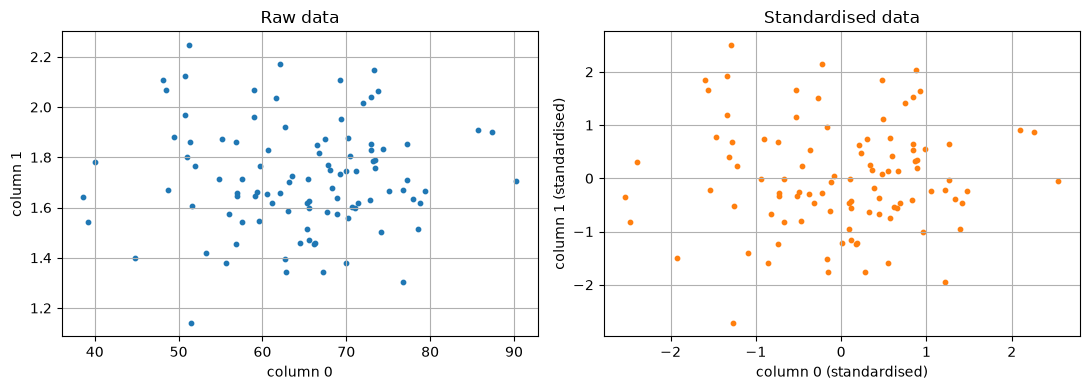

In [4]:
data = np.loadtxt("../data/data.txt")
print("shape:", data.shape)

mu = data.mean(axis=0)
sd = data.std(axis=0)
print("column means:", mu)
print("column stds :", sd)

z = (data - mu) / sd          # (N, 2) - (2,) broadcasts down the rows

print("means are 0:", np.allclose(z.mean(axis=0), 0.0))
print("stds  are 1:", np.allclose(z.std(axis=0), 1.0))

plt.figure(figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.scatter(data[:, 0], data[:, 1], s=10)
plt.xlabel("column 0")
plt.ylabel("column 1")
plt.title("Raw data")
plt.grid()

plt.subplot(1, 2, 2)
plt.scatter(z[:, 0], z[:, 1], s=10, color="C1")
plt.xlabel("column 0 (standardised)")
plt.ylabel("column 1 (standardised)")
plt.title("Standardised data")
plt.grid()
plt.tight_layout()

## Question 3. Broadcasting rules

For each of the following pairs of shapes, first work out **on paper** whether
the two arrays broadcast, and if they do, what the shape of the result is:

| | shape A | shape B |
|---|---|---|
| (a) | `(3, 4)` | `(4,)` |
| (b) | `(3, 4)` | `(3,)` |
| (c) | `(5, 1)` | `(1, 6)` |
| (d) | `(8, 1, 6, 1)` | `(7, 1, 5)` |
| (e) | `(2, 3)` | `(3, 2)` |

1. Write down your five predictions in a markdown cell.
2. Then write a loop **over the list of shape pairs** (this loop is allowed,
   it is not a loop over array elements) that calls `np.broadcast_shapes` inside
   a `try`/`except ValueError` and prints either the resulting shape or the word
   `incompatible`. Compare with your predictions.
3. Case (b) fails. Using `np.newaxis` (or `None`), turn the second array into a
   shape that *does* broadcast against `(3, 4)`, and print the shape of the sum.
   Say in one sentence what the operation now means.

The rule is to line the two shapes up at their **rightmost** dimension and walk
leftwards. Two dimensions are compatible if they are equal or if one of them is
1; a missing dimension counts as 1. `a[:, np.newaxis]` inserts a new axis of
length 1, turning a shape `(3,)` into `(3, 1)`, which is how you get a column
vector to broadcast down the rows instead of across the columns.


In [5]:
# Predictions: (a) (3, 4)   (b) incompatible   (c) (5, 6)
#              (d) (8, 7, 6, 5)   (e) incompatible

pairs = [((3, 4), (4,)),
         ((3, 4), (3,)),
         ((5, 1), (1, 6)),
         ((8, 1, 6, 1), (7, 1, 5)),
         ((2, 3), (3, 2))]

for s1, s2 in pairs:
    try:
        print(s1, "and", s2, "->", np.broadcast_shapes(s1, s2))
    except ValueError:
        print(s1, "and", s2, "-> incompatible")

# Fixing case (b): make the (3,) array a column of shape (3, 1).
x = np.ones((3, 4))
y = np.arange(3)
print("fixed (b):", (x + y[:, np.newaxis]).shape)
# It now adds y[i] to every element of row i, instead of trying to add one
# value per column.

(3, 4) and (4,) -> (3, 4)
(3, 4) and (3,) -> incompatible
(5, 1) and (1, 6) -> (5, 6)
(8, 1, 6, 1) and (7, 1, 5) -> (8, 7, 6, 5)
(2, 3) and (3, 2) -> incompatible
fixed (b): (3, 4)


## Question 4. A pairwise distance matrix without loops

Consider these five points in the plane:

```python
p = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.5, 0.5]])
```

1. Using `np.newaxis` and broadcasting, build the array of coordinate
   differences and print its shape. It should be `(5, 5, 2)`.
2. From it, compute the matrix `D` of shape `(5, 5)` whose entry `D[i, j]` is
   the Euclidean distance between point `i` and point `j`. Do this without any
   loop. Print `D` rounded to three decimals.
3. Verify with `np.allclose` that `D` is symmetric and that its diagonal is
   zero. Verify also that you get the same `D` from `np.linalg.norm` with a
   suitable `axis` argument.
4. Display `D` with `plt.imshow`, add a colourbar, and label both axes with the
   point indices.
5. Find the indices of the two points that are farthest apart, using
   `np.argmax` together with `np.unravel_index`, and print them.

`p[:, np.newaxis, :]` has shape `(5, 1, 2)` and `p[np.newaxis, :, :]` has shape
`(1, 5, 2)`; their difference broadcasts to `(5, 5, 2)`, where entry `[i, j]` is
the vector from point `j` to point `i`. Squaring, summing over the last axis and
taking the square root then gives the distances. `np.argmax` returns a position
in the *flattened* array, and `np.unravel_index` converts that back into a
`(row, column)` pair.


diff.shape: (5, 5, 2)
[[0.    1.    1.414 1.    0.707]
 [1.    0.    1.    1.414 0.707]
 [1.414 1.    0.    1.    0.707]
 [1.    1.414 1.    0.    0.707]
 [0.707 0.707 0.707 0.707 0.   ]]
symmetric   : True
zero diag   : True
same as norm: True
farthest pair: 0 2 distance = 1.4142135623730951


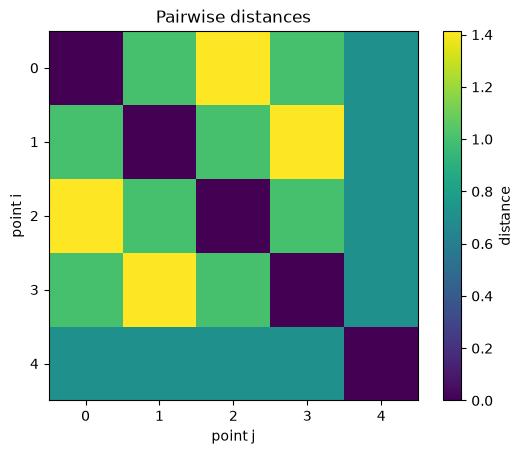

In [6]:
p = np.array([[0.0, 0.0], [1.0, 0.0], [1.0, 1.0], [0.0, 1.0], [0.5, 0.5]])

diff = p[:, np.newaxis, :] - p[np.newaxis, :, :]
print("diff.shape:", diff.shape)

D = np.sqrt((diff ** 2).sum(axis=2))
print(D.round(3))

print("symmetric   :", np.allclose(D, D.T))
print("zero diag   :", np.allclose(np.diag(D), 0.0))
print("same as norm:", np.allclose(D, np.linalg.norm(diff, axis=2)))

plt.figure()
plt.imshow(D, cmap="viridis")
plt.colorbar(label="distance")
plt.xticks(range(5))
plt.yticks(range(5))
plt.xlabel("point j")
plt.ylabel("point i")
plt.title("Pairwise distances")

i, j = np.unravel_index(np.argmax(D), D.shape)
print("farthest pair:", i, j, "distance =", D[i, j])

## Question 5. A grid of points, contours and images

1. Build `t = np.linspace(-3, 3, 200)` and use `np.meshgrid` to obtain the two
   grid arrays `X` and `Y`. Print their shapes.
2. Evaluate

$$Z = e^{-\left((X-1)^2 + (Y-0.5)^2\right)} + 0.6\, e^{-2\left((X+1.5)^2 + (Y+1)^2\right)}$$

   in a single vectorised expression.
3. Make one figure with two subplots. On the left, draw `Z` with
   `plt.contourf` and add a colourbar. On the right, draw the same `Z` with
   `plt.imshow`, passing `extent=[-3, 3, -3, 3]` and `origin='lower'` so that
   the axes carry the correct coordinates, and add a colourbar. Use a different
   colormap for each subplot.
4. Find the location `(x, y)` of the maximum of `Z` using `np.argmax` and
   `np.unravel_index`, print it, and mark it on the contour plot with a red
   cross.

`meshgrid` returns two 2-D arrays of the same shape, so any expression written
in terms of `X` and `Y` is evaluated at every grid point at once. 

Note the axis convention: the first index of `Z` runs over `y` and the second over `x`, which
is why `imshow` needs `origin='lower'` to match the contour plot. The list of
available colormaps is in `plt.colormaps`.


X.shape, Y.shape: (200, 200) (200, 200)
maximum at x = 1.010, y = 0.497, Z = 0.9999


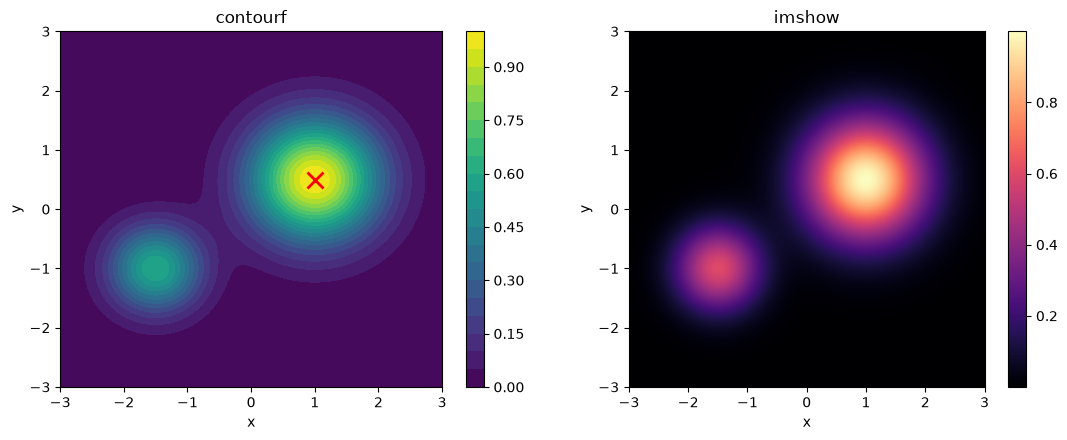

In [7]:
t = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(t, t)
print("X.shape, Y.shape:", X.shape, Y.shape)

Z = np.exp(-((X - 1)**2 + (Y - 0.5)**2)) + 0.6*np.exp(-2*((X + 1.5)**2 + (Y + 1)**2))

r, c = np.unravel_index(np.argmax(Z), Z.shape)
xmax, ymax = X[r, c], Y[r, c]
print("maximum at x = %.3f, y = %.3f, Z = %.4f" % (xmax, ymax, Z[r, c]))

plt.figure(figsize=(11, 4.5))
plt.subplot(1, 2, 1)
plt.contourf(X, Y, Z, levels=20, cmap="viridis")
plt.colorbar()
plt.plot(xmax, ymax, "rx", markersize=12, markeredgewidth=2)
plt.xlabel("x")
plt.ylabel("y")
plt.title("contourf")

plt.subplot(1, 2, 2)
plt.imshow(Z, extent=[-3, 3, -3, 3], origin="lower", cmap="magma")
plt.colorbar()
plt.xlabel("x")
plt.ylabel("y")
plt.title("imshow")
plt.tight_layout()

## Question 6. Boolean masks and an estimate of $\pi$

1. Set `np.random.seed(0)` and generate `n = 5000` points uniformly distributed
   in the square $[-1, 1) \times [-1, 1)$ using `np.random.random`. Scale and
   shift; do not use `np.random.uniform`.
2. Build a boolean mask that is `True` for the points lying inside the unit
   circle. Use it to form the two arrays `inside` and `outside`, and print
   their shapes.
3. Scatter the two sets in different colours on the same axes, draw the unit
   circle itself as a line, and use `plt.axis('equal')`.
4. The area of the circle is $\pi$ and the area of the square is 4, so the
   fraction of points inside estimates $\pi/4$. Print your estimate of $\pi$
   and its absolute error. Do this without any loop.

A comparison such as `r2 <= 1.0` gives a boolean array of the same shape.
Indexing with that array, `pts[mask]`, selects the rows where it is `True`, and
`~mask` is its negation. Because `True` counts as 1, `mask.sum()` is simply the
number of points inside.


inside : (3925, 2)
outside: (1075, 2)
estimate of pi : 3.14
absolute error : 0.0015926535897929917


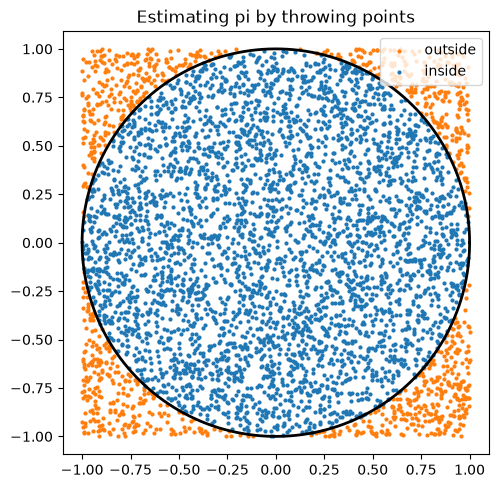

In [8]:
np.random.seed(0)
n = 5000
pts = np.random.random((n, 2)) * 2 - 1        # uniform in [-1, 1)

mask = (pts ** 2).sum(axis=1) <= 1.0
inside = pts[mask]
outside = pts[~mask]
print("inside :", inside.shape)
print("outside:", outside.shape)

theta = np.linspace(0, 2 * np.pi, 400)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(outside[:, 0], outside[:, 1], s=4, color="C1", label="outside")
plt.scatter(inside[:, 0], inside[:, 1], s=4, color="C0", label="inside")
plt.plot(np.cos(theta), np.sin(theta), "k-", lw=2)
plt.axis("equal")
plt.legend()
plt.title("Estimating pi by throwing points")

estimate = 4 * mask.sum() / n
print("estimate of pi :", estimate)
print("absolute error :", abs(estimate - np.pi))

## Question 7. Comparing batsmen with boolean masks

Load `data/sachin.txt`, `data/kohli.txt` and `data/rohit.txt` with
`np.loadtxt`. Each file holds one ODI score per line.

For each player, compute and print, using boolean masks and no loop over
innings:

1. the number of innings and the mean score,
2. the number of scores of 50 or more, and the number of 100 or more,
3. the conversion rate $P(X \geq 100 \mid X \geq 50)$,
4. the mean score in those innings where he passed 50.

Then draw a grouped bar chart comparing the three players on the counts of
50-plus and 100-plus scores, with the player names as tick labels and a legend.

Finally, write two or three sentences comparing the players. Say clearly which
comparisons are fair and which are affected by the different number of innings.

A mask such as `m50 = scores >= 50` can be used three ways: `m50.sum()` counts
the innings, `scores[m50]` selects those scores, and `(scores >= 100).sum() /
m50.sum()` is the conditional probability. For the grouped bars, plot the first
group at `x = np.arange(3) - 0.2` and the second at `x + 0.2` with
`width=0.4`, then set the tick labels with `plt.xticks`.


Sachin   innings= 452  mean= 40.77  50+=145  100+= 49  P(100|50)=0.338  mean given 50+= 90.14
Kohli    innings= 290  mean= 48.90  50+=125  100+= 51  P(100|50)=0.408  mean given 50+= 91.47
Rohit    innings= 265  mean= 42.14  50+= 90  100+= 32  P(100|50)=0.356  mean given 50+= 93.03


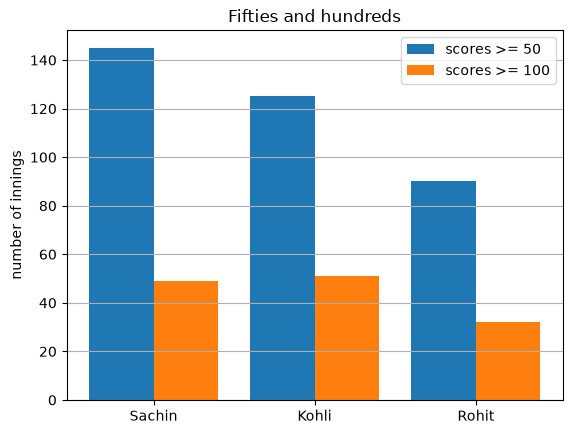

In [10]:
sachin = np.loadtxt("../data/sachin.txt")
kohli = np.loadtxt("../data/kohli.txt")
rohit = np.loadtxt("../data/rohit.txt")

names = ["Sachin", "Kohli", "Rohit"]
players = [sachin, kohli, rohit]
fifties, hundreds = [], []

for name, s in zip(names, players):          # a loop over 3 players, not innings
    m50 = s >= 50
    m100 = s >= 100
    fifties.append(m50.sum())
    hundreds.append(m100.sum())
    print(f"{name:8s} innings={s.size:4d}  mean={s.mean():6.2f}  "
          f"50+={m50.sum():3d}  100+={m100.sum():3d}  "
          f"P(100|50)={m100.sum()/m50.sum():.3f}  "
          f"mean given 50+={s[m50].mean():6.2f}")

x = np.arange(3)
plt.figure()
plt.bar(x - 0.2, fifties, width=0.4, label="scores >= 50")
plt.bar(x + 0.2, hundreds, width=0.4, label="scores >= 100")
plt.xticks(x, names)
plt.ylabel("number of innings")
plt.title("Fifties and hundreds")
plt.legend()
plt.grid(axis="y")

# Comment: the raw counts of 50s and 100s favour Sachin simply because he
# played far more innings (452 against 290 and 265), so they are not a fair
# comparison on their own. The mean score and the conversion rate
# P(X >= 100 | X >= 50) are per-innings quantities and are fair: Kohli leads on
# both, with the highest mean and the best conversion of a fifty into a
# hundred. The mean score given a fifty is close for all three, so the
# difference lies in how often they reach fifty, not in what they do afterwards.

## Question 8. Splitting, stacking and concatenating

1. Build `a = np.arange(1, 13).reshape(3, 4)` and print it.
2. Use `np.hsplit` to split `a` into two blocks of shape `(3, 2)`, and
   `np.vsplit` to split it into three rows of shape `(1, 4)`. Print the shapes.
3. Rebuild `a` from each set of pieces with `np.concatenate`, choosing the
   right `axis`, and confirm with `np.array_equal` that you get the original
   back.
4. For `r = np.array([1, 2, 3])` and `s = np.array([4, 5, 6])`, print the shape
   of `np.stack((r, s))`, `np.stack((r, s), axis=1)`, `np.hstack((r, s))` and
   `np.vstack((r, s))`. In one or two sentences, explain the difference between
   `stack` and `concatenate`.
5. Using `np.concatenate` only, build the $6 \times 8$ block matrix

$$B = \begin{bmatrix} a & 2a \\ 3a & 4a \end{bmatrix}$$

   print its shape, and display it with `plt.imshow` and a colourbar.

`concatenate` joins arrays along an axis that already exists, so the result has
the same number of dimensions as the inputs. `stack` creates a **new** axis, so
the result has one dimension more; `np.stack((r, s))` gives shape `(2, 3)`
while `np.stack((r, s), axis=1)` gives `(3, 2)`. For the block matrix, build the
two rows of blocks first and then join them.


[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
hsplit shapes: (3, 2) (3, 2)
vsplit shapes: [(1, 4), (1, 4), (1, 4)]
rebuilt from hsplit: True
rebuilt from vsplit: True
stack        : (2, 3)
stack axis=1 : (3, 2)
hstack       : (6,)
vstack       : (2, 3)
B.shape: (6, 8)


Text(0.5, 1.0, 'Block matrix [[a, 2a], [3a, 4a]]')

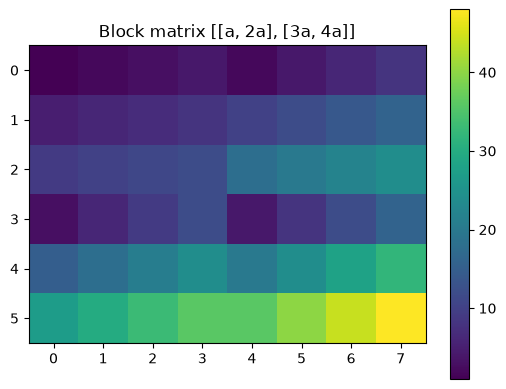

In [11]:
a = np.arange(1, 13).reshape(3, 4)
print(a)

left, right = np.hsplit(a, 2)
print("hsplit shapes:", left.shape, right.shape)

rows = np.vsplit(a, 3)
print("vsplit shapes:", [r.shape for r in rows])

print("rebuilt from hsplit:", np.array_equal(np.concatenate((left, right), axis=1), a))
print("rebuilt from vsplit:", np.array_equal(np.concatenate(rows, axis=0), a))

r = np.array([1, 2, 3])
s = np.array([4, 5, 6])
print("stack        :", np.stack((r, s)).shape)
print("stack axis=1 :", np.stack((r, s), axis=1).shape)
print("hstack       :", np.hstack((r, s)).shape)
print("vstack       :", np.vstack((r, s)).shape)
# concatenate joins along an axis that already exists, so the number of
# dimensions is unchanged; stack introduces a new axis, so the result has one
# dimension more than the inputs.

top = np.concatenate((a, 2 * a), axis=1)
bottom = np.concatenate((3 * a, 4 * a), axis=1)
B = np.concatenate((top, bottom), axis=0)
print("B.shape:", B.shape)

plt.figure()
plt.imshow(B, cmap="viridis")
plt.colorbar()
plt.title("Block matrix [[a, 2a], [3a, 4a]]")

## Question 9. Linear systems and eigenvalues

Consider

```python
A = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
b = np.array([8.0, -11.0, -3.0])
```

1. Solve $Ax = b$ with `np.linalg.solve` and print `x`. Verify with
   `np.allclose` that `A @ x` equals `b`.
2. Print `np.linalg.det(A)`, compute `np.linalg.inv(A) @ b`, and confirm that
   it agrees with your `x`. In one sentence, say which of the two routes you
   would prefer in practice and why.
3. Now take the symmetric matrix

```python
S = np.array([[2.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]])
```

   Use `np.linalg.eig` to get its eigenvalues `w` and eigenvectors `V`, and
   print them. Remember that the eigenvectors are the **columns** of `V`.
4. For each eigenvalue, verify with `np.allclose` that $S v = \lambda v$.
5. Check that `V.T @ V` is the identity and that `V @ np.diag(w) @ V.T`
   reproduces `S`. Say in one sentence why this works for a symmetric matrix.
6. Print `np.linalg.norm(S)` and confirm it equals the square root of the sum
   of the squares of all the entries.

`np.linalg.eig` returns a tuple, so `w, V = np.linalg.eig(S)`. Column `k` is
`V[:, k]`, which pairs with the eigenvalue `w[k]`. You may use a `for` loop over
the three eigenvalues in part 4; that is a loop over three columns, not over
array elements.

In [12]:
A = np.array([[2.0, 1.0, -1.0], [-3.0, -1.0, 2.0], [-2.0, 1.0, 2.0]])
b = np.array([8.0, -11.0, -3.0])

x = np.linalg.solve(A, b)
print("x =", x)
print("A @ x == b:", np.allclose(A @ x, b))

print("det(A) =", np.linalg.det(A))
print("inv(A) @ b =", np.linalg.inv(A) @ b)
print("same answer:", np.allclose(np.linalg.inv(A) @ b, x))
# Prefer solve: it is faster and numerically better behaved than forming the
# inverse and multiplying, which does more work and loses more accuracy.

S = np.array([[2.0, 1.0, 0.0], [1.0, 3.0, 1.0], [0.0, 1.0, 2.0]])
w, V = np.linalg.eig(S)
print("eigenvalues :", w)
print("eigenvectors (columns):")
print(V)

for k in range(3):
    print(f"S v{k} == w{k} v{k}:", np.allclose(S @ V[:, k], w[k] * V[:, k]))

print("V.T @ V is I :", np.allclose(V.T @ V, np.identity(3)))
print("V diag(w) V.T is S:", np.allclose(V @ np.diag(w) @ V.T, S))
# A real symmetric matrix has real eigenvalues and an orthonormal set of
# eigenvectors, so V is orthogonal and V.T is its inverse.

print("norm(S)     :", np.linalg.norm(S))
print("sqrt of sum of squares:", np.sqrt((S ** 2).sum()))

x = [ 2.  3. -1.]
A @ x == b: True
det(A) = -0.9999999999999996
inv(A) @ b = [ 2.  3. -1.]
same answer: True
eigenvalues : [4. 2. 1.]
eigenvectors (columns):
[[-4.08248290e-01  7.07106781e-01  5.77350269e-01]
 [-8.16496581e-01 -3.46674672e-16 -5.77350269e-01]
 [-4.08248290e-01 -7.07106781e-01  5.77350269e-01]]
S v0 == w0 v0: True
S v1 == w1 v1: True
S v2 == w2 v2: True
V.T @ V is I : True
V diag(w) V.T is S: True
norm(S)     : 4.58257569495584
sqrt of sum of squares: 4.58257569495584


## Question 10. A least squares fit and the value of $g$

`data/pendulum.txt` holds the length $L$ of a simple pendulum in the first
column and its time period $T$ in the second.

1. Load the two columns with `np.loadtxt` and `unpack=True`, and compute
   `tsq = T**2`.
2. Theory says $T = 2\pi\sqrt{L/g}$, so $T^2 = (4\pi^2/g)\, L$, a straight
   line through the origin. Fit the more general line $T^2 = mL + c$ by
   building the design matrix

$$A = \begin{bmatrix} L_1 & 1 \\ L_2 & 1 \\ \vdots & \vdots \\ L_N & 1
\end{bmatrix}$$

   and calling `np.linalg.lstsq(A, tsq, rcond=None)`. Print $m$ and $c$.
3. Plot the data as points and the fitted line on the same axes, with axis
   labels and a legend.
4. From the slope, estimate $g = 4\pi^2/m$. Print your estimate and its
   percentage difference from $9.81\ \mathrm{m/s^2}$.
5. Compute the residuals $T^2 - Ap$, print the norm of the residual vector and
   the coefficient of determination $R^2 = 1 - \mathrm{SS_{res}}/
   \mathrm{SS_{tot}}$, and plot the residuals against $L$ in a second figure.
   In two sentences, say whether the straight line is a good model here and what
   the intercept $c$ tells you.

`np.array([L, np.ones_like(L)])` has shape `(2, N)`, so transpose it to get the
`(N, 2)` design matrix. `lstsq` returns a tuple whose **first** element is the
solution vector; `rcond=None` silences a future-version warning.
$\mathrm{SS_{tot}}$ is the sum of squares of `tsq - tsq.mean()`.


design matrix shape: (90, 2)
m = 4.1415, c = 0.0736
g = 9.5324 m/s^2
percentage difference from 9.81: 2.83 %
residual norm: 0.7975560345300042
R^2 = 0.9939316003682754


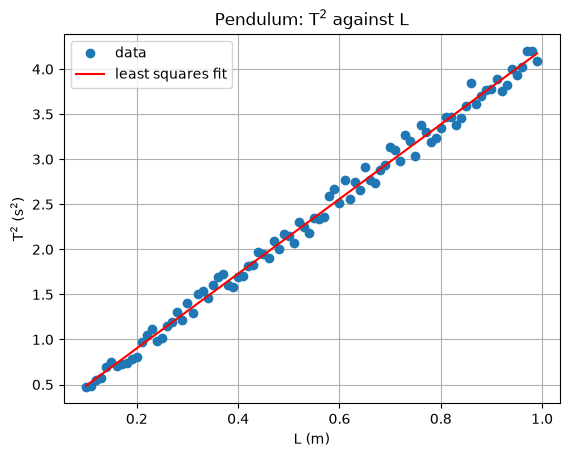

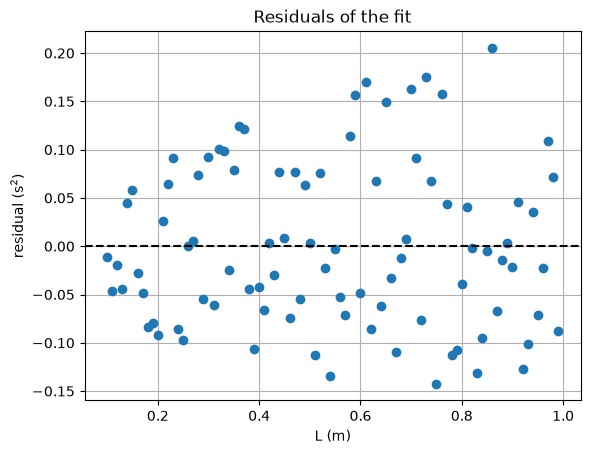

In [13]:
L, T = np.loadtxt("../data/pendulum.txt", unpack=True)
tsq = T ** 2

A = np.array([L, np.ones_like(L)]).T
print("design matrix shape:", A.shape)

coef = np.linalg.lstsq(A, tsq, rcond=None)[0]
m, c = coef
print("m = %.4f, c = %.4f" % (m, c))

plt.figure()
plt.plot(L, tsq, "o", label="data")
plt.plot(L, A @ coef, "r-", label="least squares fit")
plt.xlabel("L (m)")
plt.ylabel("T$^2$ (s$^2$)")
plt.title("Pendulum: T$^2$ against L")
plt.legend()
plt.grid()

g = 4 * np.pi ** 2 / m
print("g = %.4f m/s^2" % g)
print("percentage difference from 9.81: %.2f %%" % (abs(g - 9.81) / 9.81 * 100))

res = tsq - A @ coef
ss_res = (res ** 2).sum()
ss_tot = ((tsq - tsq.mean()) ** 2).sum()
print("residual norm:", np.linalg.norm(res))
print("R^2 =", 1 - ss_res / ss_tot)

plt.figure()
plt.plot(L, res, "o")
plt.axhline(0.0, color="k", ls="--")
plt.xlabel("L (m)")
plt.ylabel("residual (s$^2$)")
plt.title("Residuals of the fit")
plt.grid()

# Comment: R^2 is about 0.994 and the residuals scatter about zero without an
# obvious pattern, so the straight line is a good model for this data. The
# intercept c is small compared with the values of T^2, which is consistent
# with the theoretical line passing through the origin; a non-zero c reflects
# measurement error rather than physics.